<a href="https://colab.research.google.com/github/vinitpatil519/Wafer-Map-Pattern-Intelligence/blob/main/WaferAiwithMonteCarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Detected Google Colab environment.
⚙️ Running on Device: cpu
🚀 STARTING WAFER MAP YIELD INTELLIGENCE PLATFORM

🔐 Setting up Kaggle API...
✅ input/kaggle.json created and protected.
✅ Kaggle API Connected as: vinitonterminal

📦 Downloading Datasets... (This may take a moment)
   ⬇️ Downloading wm811k-images...
   ⬇️ Downloading wm811k-original...
   ⬇️ Downloading multi-class...
   ⬇️ Downloading mixed-type...
   ⬇️ Downloading simulated...
✅ All datasets ready.

📂 Scanning dataset directories...
   Found 7913 potential images.


Indexing Images: 100%|██████████| 7913/7913 [00:00<00:00, 380836.59it/s]

✅ Indexed 7716 valid labeled images.

🏗️ Training EfficientNet-B0 on 6172 samples...



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


...

Epoch 3: 100%|██████████| 193/193 [28:20<00:00,  8.81s/it]


   Train Loss: 0.1145 | Val Acc: 0.9760
🔍 Fitting Open-Set Detector (Mahalanobis)...


Extracting Features: 100%|██████████| 193/193 [05:34<00:00,  1.73s/it]


✅ Open-Set Threshold Set: 44.5274

🏭 Training Autoencoder (Anomaly Detection)...
   Epoch [1/5] AE Loss: 1.596410
   Epoch [2/5] AE Loss: 1.428902
   Epoch [3/5] AE Loss: 1.406767
   Epoch [4/5] AE Loss: 1.427134
   Epoch [5/5] AE Loss: 1.403507

🔍 Running Evaluation...
🎨 Generating Visualizations...


Exception ignored in: <function BaseCAM.__del__ at 0x7ce1e28f0cc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_grad_cam/base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'


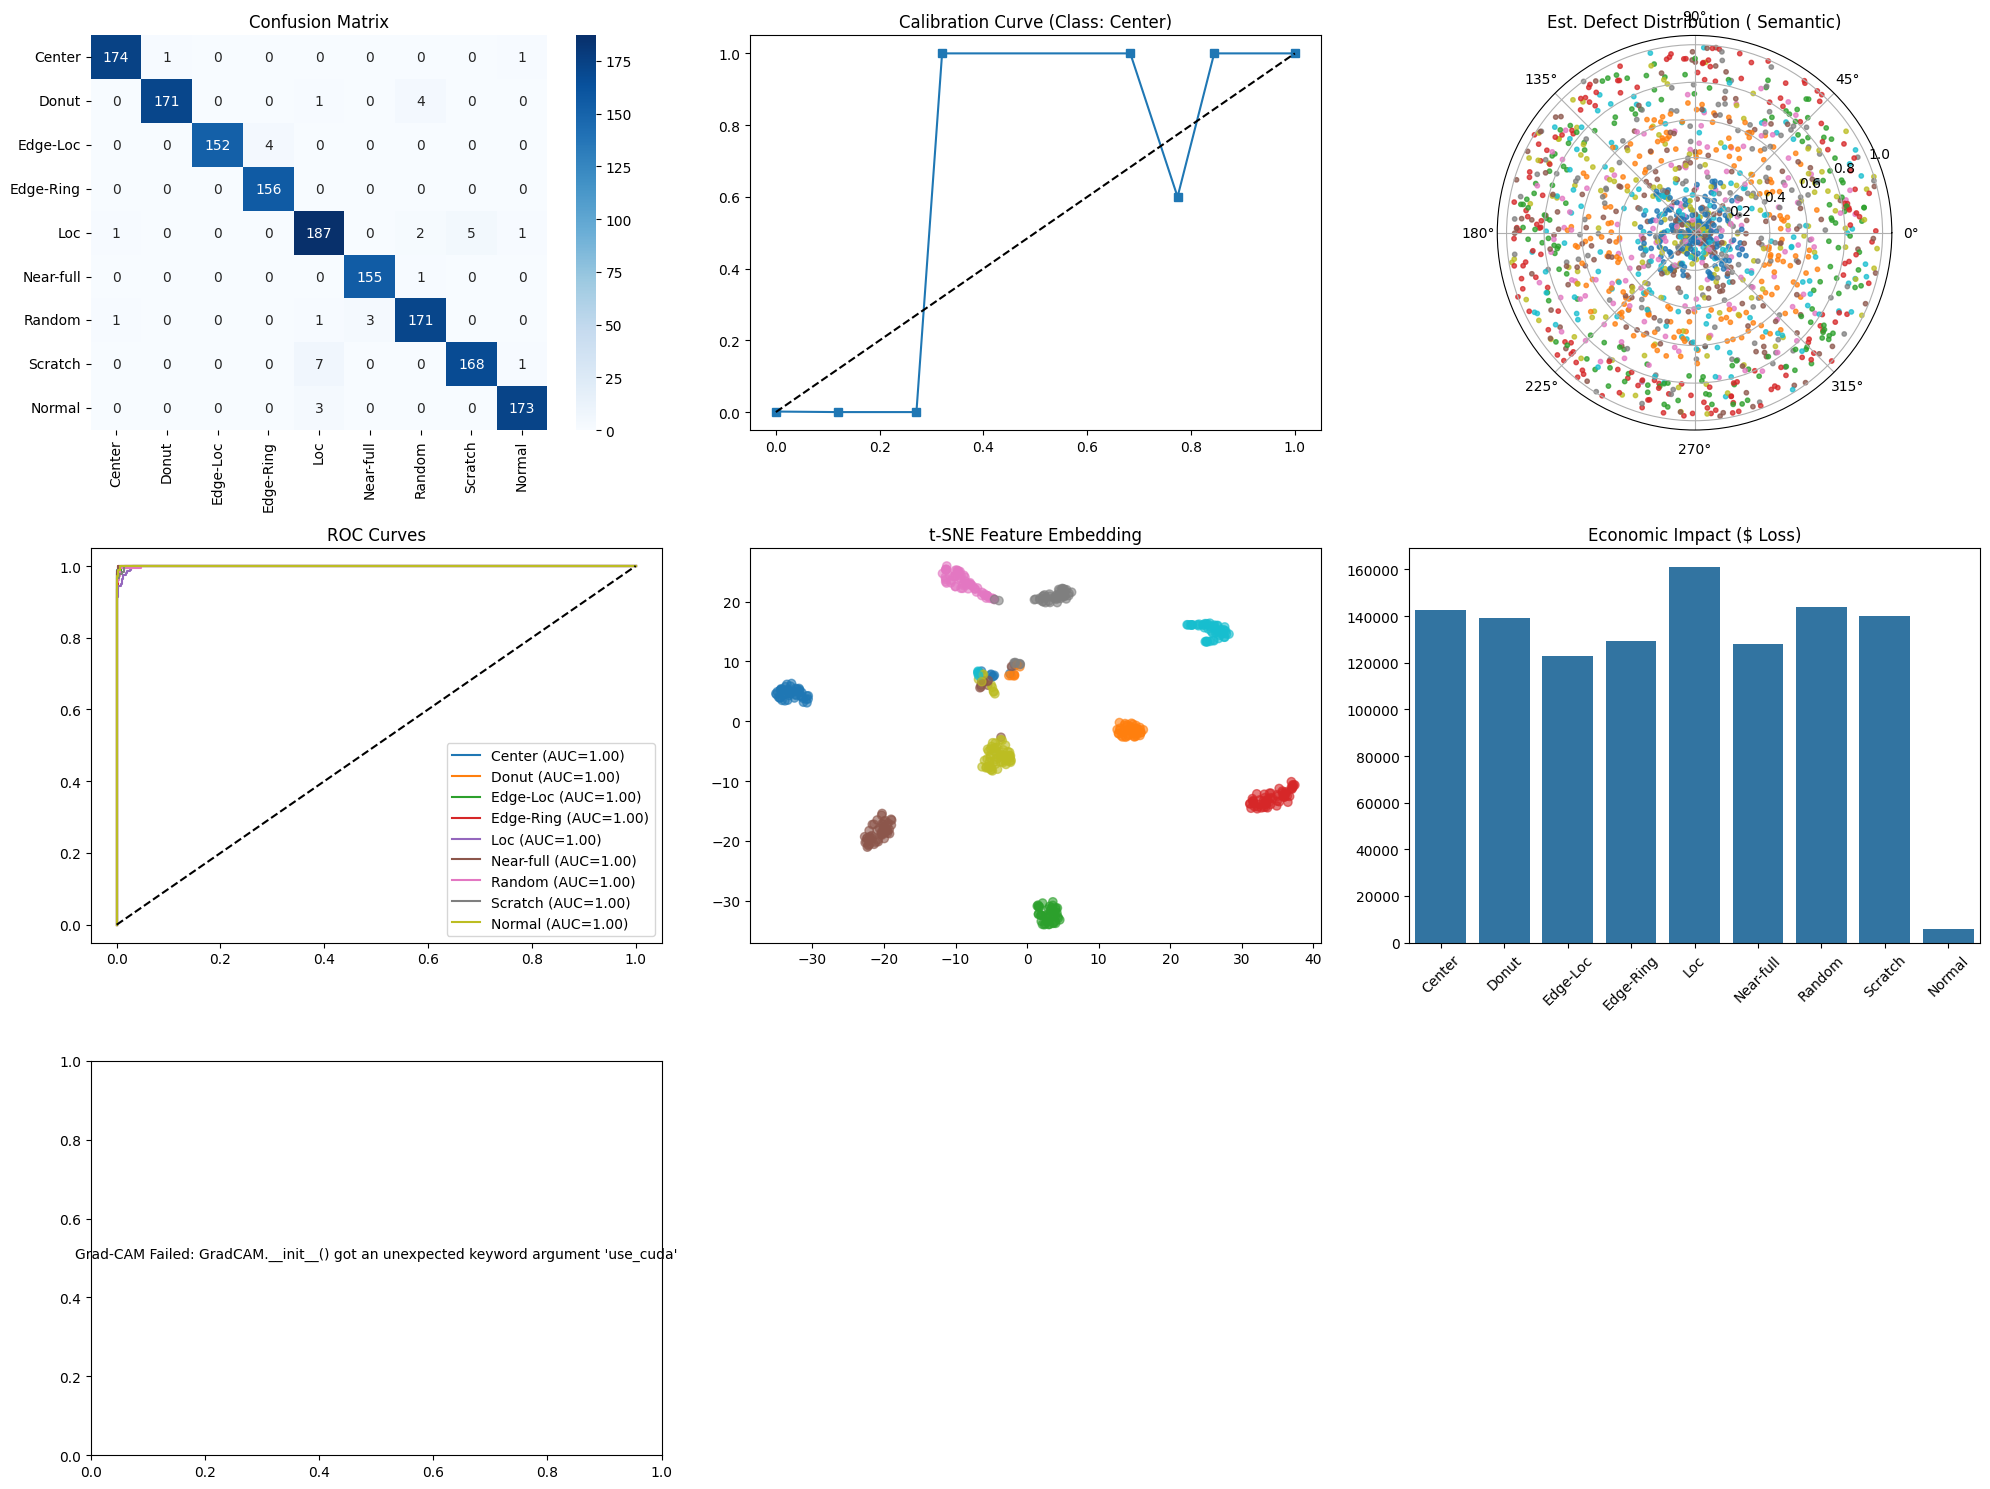

              precision    recall  f1-score   support

      Center       0.99      0.99      0.99       176
       Donut       0.99      0.97      0.98       176
    Edge-Loc       1.00      0.97      0.99       156
   Edge-Ring       0.97      1.00      0.99       156
         Loc       0.94      0.95      0.95       196
   Near-full       0.98      0.99      0.99       156
      Random       0.96      0.97      0.97       176
     Scratch       0.97      0.95      0.96       176
      Normal       0.98      0.98      0.98       176

    accuracy                           0.98      1544
   macro avg       0.98      0.98      0.98      1544
weighted avg       0.98      0.98      0.98      1544

✅ PIPELINE COMPLETE


In [ ]:
import os
os.system("pip install -q kaggle seaborn matplotlib scikit-learn torch torchvision umap-learn grad-cam")

import json

try:
    from google.colab import drive
    IN_COLAB = True
    print("✅ Detected Google Colab environment.")
except ImportError:
    IN_COLAB = False
    print("⚠️ Not running in Google Colab. Some features might need adjustment.")

KAGGLE_USERNAME = "vinitonterminal"
KAGGLE_KEY = "KGAT_bb536350dde30c509ed938f03981832e"

def setup_kaggle():
    print("\n🔐 Setting up Kaggle API...")
    kaggle_dir = os.path.expanduser("~/.kaggle")
    if not os.path.exists(kaggle_dir):
        os.makedirs(kaggle_dir)

    kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
    with open(kaggle_json_path, "w") as f:
        json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

    os.chmod(kaggle_json_path, 0o600)
    print("✅ input/kaggle.json created and protected.")

    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        print(f"✅ Kaggle API Connected as: {api.get_config_value('username')}")
        return api
    except Exception as e:
        print(f"❌ Kaggle API Connection Failed: {e}")
        return None

DATASETS = {
    "wm811k-images": "muhammedjunayed/wm811k-silicon-wafer-map-dataset-image",
    "wm811k-original": "qingyi/wm811k-wafer-map",
    "multi-class": "drtawfikrrahman/multi-class-semiconductor-wafer-image-dataset",
    "mixed-type": "co1d7era/mixedtype-wafer-defect-datasets",
    "simulated": "alexandremoritz/simulated-analog-wafer-pattern-recognition"
}

def download_datasets(api):
    print("\n📦 Downloading Datasets... (This may take a moment)")
    os.makedirs("datasets", exist_ok=True)

    for name, dataset_path in DATASETS.items():
        dataset_dir = os.path.join("datasets", name)
        if not os.path.exists(dataset_dir):
            print(f"   ⬇️ Downloading {name}...")
            os.system(f"kaggle datasets download -d {dataset_path} -p datasets/{name} --unzip")
        else:
            print(f"   ✅ {name} already exists.")
    print("✅ All datasets ready.")

import time
import random
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, roc_curve,
                             matthews_corrcoef, cohen_kappa_score, log_loss, brier_score_loss,
                             classification_report, precision_recall_curve, auc)
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.covariance import EmpiricalCovariance

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn.functional as F

try:
    import umap
except ImportError:
    print("⚠️ UMAP not installed, skipping UMAP visualization.")
    umap = None

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("⚠️ Grad-CAM not installed, using simple activation mapping.")

class Config:
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 3
    LEARNING_RATE = 1e-3
    NUM_CLASSES = 9
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    LABELS = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'Normal']

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(Config.SEED)
print(f"⚙️ Running on Device: {Config.DEVICE}")

class WaferDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (Config.IMG_SIZE, Config.IMG_SIZE), (0, 0, 0))

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

def load_data():
    print("\n📂 Scanning dataset directories...")
    label_map = {l.lower(): l for l in Config.LABELS}
    label_map['none'] = 'Normal'
    label_map['center'] = 'Center'
    label_map['donut'] = 'Donut'
    label_map['edge-loc'] = 'Edge-Loc'
    label_map['edge-ring'] = 'Edge-Ring'
    label_map['loc'] = 'Loc'
    label_map['near-full'] = 'Near-full'
    label_map['random'] = 'Random'
    label_map['scratch'] = 'Scratch'

    search_path = "datasets/**/*.jpg"
    image_files = glob.glob(search_path, recursive=True)
    image_files += glob.glob("datasets/**/*.png", recursive=True)

    print(f"   Found {len(image_files)} potential images.")

    valid_images = []
    valid_labels = []

    for img_path in tqdm(image_files, desc="Indexing Images"):
        dirname = os.path.basename(os.path.dirname(img_path)).lower()
        filename = os.path.basename(img_path).lower()

        mapped_label = None
        for key, val in label_map.items():
            if key in dirname:
                mapped_label = val
                break

        if not mapped_label:
             for key, val in label_map.items():
                if key in filename:
                    mapped_label = val
                    break

        if mapped_label:
            valid_images.append(img_path)
            valid_labels.append(Config.LABELS.index(mapped_label))

    print(f"✅ Indexed {len(valid_images)} valid labeled images.")
    return np.array(valid_images), np.array(valid_labels)

train_transforms = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class WaferClassifier(nn.Module):
    def __init__(self, num_classes=Config.NUM_CLASSES):
        super(WaferClassifier, self).__init__()
        self.backbone = models.efficientnet_b0(pretrained=True)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self.features = None

    def forward(self, x):
        features = self.backbone(x)
        self.features = features
        out = self.fc(features)
        return out

class OpenSetDetector:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.centroids = None
        self.cov_inv = None
        self.threshold = None

    def fit(self, train_loader):
        print("🔍 Fitting Open-Set Detector (Mahalanobis)...")
        self.model.eval()
        features_list = []
        labels_list = []

        with torch.no_grad():
            for imgs, lbls in tqdm(train_loader, desc="Extracting Features"):
                imgs = imgs.to(self.device)
                _ = self.model(imgs)
                feats = self.model.features.cpu().numpy()
                features_list.append(feats)
                labels_list.append(lbls.numpy())

        features = np.concatenate(features_list)
        labels = np.concatenate(labels_list)

        unique_classes = np.unique(labels)
        self.centroids = {}
        for cls in unique_classes:
            self.centroids[cls] = np.mean(features[labels == cls], axis=0)

        ec = EmpiricalCovariance(assume_centered=False)
        ec.fit(features - np.array([self.centroids[l] for l in labels]))
        self.cov_inv = torch.tensor(ec.precision_, dtype=torch.float32).to(self.device)
        self.centroids = {k: torch.tensor(v, dtype=torch.float32).to(self.device) for k, v in self.centroids.items()}

        dists = self._compute_mahalanobis(torch.tensor(features).to(self.device), torch.tensor(labels).to(self.device))
        self.threshold = np.percentile(dists.cpu().numpy(), 95)
        print(f"✅ Open-Set Threshold Set: {self.threshold:.4f}")

    def _compute_mahalanobis(self, features, labels=None):
        if labels is not None:
            batch_dists = []
            for i in range(len(features)):
                f = features[i]
                l = labels[i].item()
                c = self.centroids[l]
                delta = f - c
                d = torch.sqrt(torch.matmul(torch.matmul(delta, self.cov_inv), delta))
                batch_dists.append(d)
            return torch.tensor(batch_dists).to(self.device)
        else:
            batch_dists = []
            for cls_idx, centroid in self.centroids.items():
                delta = features - centroid
                m = torch.matmul(delta, self.cov_inv)
                d = torch.sqrt(torch.sum(m * delta, dim=1))
                batch_dists.append(d.unsqueeze(1))

            dists_tensor = torch.cat(batch_dists, dim=1)
            min_dists, _ = torch.min(dists_tensor, dim=1)
            return min_dists

    def predict(self, features):
        dists = self._compute_mahalanobis(features)
        is_unknown = dists > self.threshold
        return is_unknown, dists

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, 2, 1, 1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

def train_autoencoder(model, train_loader, epochs=5):
    print("\n🏭 Training Autoencoder (Anomaly Detection)...")
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.to(Config.DEVICE)
    model.train()

    normal_idx = Config.LABELS.index('Normal')
    history = []

    for epoch in range(epochs):
        curr_loss = 0.0
        count = 0
        for images, labels in train_loader:
            mask = labels == normal_idx
            if mask.sum() == 0: continue

            imgs = images[mask].to(Config.DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, imgs)
            loss.backward()
            optimizer.step()
            curr_loss += loss.item() * imgs.size(0)
            count += imgs.size(0)

        avg_loss = curr_loss / count if count > 0 else 0
        history.append(avg_loss)
        print(f"   Epoch [{epoch+1}/{epochs}] AE Loss: {avg_loss:.6f}")
    return model, history


class EconomicImpact:
    def __init__(self, revenue_per_die=5.0, wafers_per_month=1000, dies_per_wafer=500):
        self.rev_die = revenue_per_die
        self.vol = wafers_per_month
        self.dpw = dies_per_wafer

    def estimate_loss(self, defect_counts):
        total_wafers = sum(defect_counts.values())
        if total_wafers == 0: return {}, {}

        scale = self.vol / total_wafers
        loss_breakdown = {}
        monthly_loss = 0

        for defect, count in defect_counts.items():
            factor = 0.02 if defect == 'Normal' else 0.50
            loss = count * scale * self.dpw * factor * self.rev_die
            monthly_loss += loss
            loss_breakdown[defect] = loss

        results = {
            "Yield Rate": f"{(defect_counts.get('Normal',0)/total_wafers)*100:.2f}%",
            "Monthly Revenue Loss": f"${monthly_loss:,.2f}",
            "Priority Action": max(loss_breakdown, key=loss_breakdown.get)
        }
        return results, loss_breakdown

ROOT_CAUSE_DB = {
    'Center': {'Stage': 'Spin Coating', 'Cause': 'Dispense nozzle misalignment', 'Action': 'Recalibrate coater arm'},
    'Donut': {'Stage': 'Etching', 'Cause': 'Radial non-uniformity in plasma', 'Action': 'Check RF power distribution'},
    'Edge-Loc': {'Stage': 'Handling', 'Cause': 'Robot end-effector slip', 'Action': 'Clean/Replace vacuum pads'},
    'Edge-Ring': {'Stage': 'CMP / Etch', 'Cause': 'Edge bead removal failure', 'Action': 'Inspect edge clamp/exclusion ring'},
    'Loc': {'Stage': 'Lithography', 'Cause': 'Particle contamination on reticle', 'Action': 'Pellicle inspection required'},
    'Near-full': {'Stage': 'Deposition', 'Cause': 'Gas flow interruption', 'Action': 'Check mass flow controllers'},
    'Random': {'Stage': 'Multi-stage', 'Cause': 'Cleanroom air quality spike', 'Action': 'Check filter fan units (FFU)'},
    'Scratch': {'Stage': 'Handling/CMP', 'Cause': 'Mechanical abrasion', 'Action': 'Check transport slots/cassettes'},
    'Normal': {'Stage': 'N/A', 'Cause': 'Process Nominal', 'Action': 'Maintain baseline'}
}

def main():
    print("🚀 STARTING WAFER MAP YIELD INTELLIGENCE PLATFORM")

    api = setup_kaggle()
    if not api: return
    download_datasets(api)

    file_paths, labels = load_data()
    X_train, X_val, y_train, y_val = train_test_split(file_paths, labels, test_size=0.2, stratify=labels, random_state=Config.SEED)

    train_dataset = WaferDataset(X_train, y_train, transform=train_transforms)
    val_dataset = WaferDataset(X_val, y_val, transform=val_transforms)
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"\n🏗️ Training EfficientNet-B0 on {len(X_train)} samples...")
    model = WaferClassifier().to(Config.DEVICE)
    class_counts = np.bincount(labels)
    class_weights = torch.tensor([len(labels) / (len(class_counts) * c) for c in class_counts], dtype=torch.float32).to(Config.DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=Config.LEARNING_RATE, steps_per_epoch=len(train_loader), epochs=Config.EPOCHS)

    # Initialize scaler conditionally
    if Config.DEVICE.type == "cuda":
        scaler = torch.cuda.amp.GradScaler()
    else:
        scaler = None # Scaler is not used on CPU

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(Config.EPOCHS):
        model.train()
        running_loss = 0.0
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, targets = images.to(Config.DEVICE), targets.to(Config.DEVICE)
            optimizer.zero_grad()

            if Config.DEVICE.type == "cuda" and scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, targets)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

            scheduler.step()
            running_loss += loss.item() * images.size(0)

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(Config.DEVICE), targets.to(Config.DEVICE)
                outputs = model(images)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * images.size(0)
                val_correct += (torch.max(outputs, 1)[1] == targets).sum().item()

        history['train_loss'].append(running_loss/len(train_dataset))
        history['val_loss'].append(val_loss/len(val_dataset))
        history['val_acc'].append(val_correct/len(val_dataset))
        print(f"   Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

    osd = OpenSetDetector(model, Config.DEVICE)
    osd.fit(train_loader)

    ae = ConvAutoencoder()
    ae, ae_hist = train_autoencoder(ae, train_loader)

    print("\n🔍 Running Evaluation...")
    model.eval()
    y_true, y_pred, y_probs, embeddings = [], [], [], []

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(Config.DEVICE)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(targets.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
            embeddings.extend(model.features.cpu().numpy())

    y_true, y_pred, y_probs, embeddings = np.array(y_true), np.array(y_pred), np.array(y_probs), np.array(embeddings)

    print("🎨 Generating Visualizations...")
    plt.figure(figsize=(20, 15))

    plt.subplot(3, 3, 1)
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=Config.LABELS, yticklabels=Config.LABELS, cmap='Blues')
    plt.title("Confusion Matrix")

    plt.subplot(3, 3, 2)
    prob_pos = y_probs[:, 0]
    truth = (y_true == 0).astype(int)
    fraction_of_positives, mean_predicted_value = calibration_curve(truth, prob_pos, n_bins=10)
    plt.plot(mean_predicted_value, fraction_of_positives, "s-")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("Calibration Curve (Class: Center)")

    plt.subplot(3, 3, 3, projection='polar')
    radii = []
    thetas = []
    colors = []

    for i in range(len(y_pred)):
        lbl = Config.LABELS[y_pred[i]]
        if lbl == 'Center':
            r = np.random.uniform(0, 0.3)
        elif lbl == 'Edge-Ring':
            r = np.random.uniform(0.8, 1.0)
        elif lbl == 'Edge-Loc':
            r = np.random.uniform(0.7, 0.95)
        elif lbl == 'Donut':
            r = np.random.uniform(0.4, 0.7)
        elif lbl == 'Near-full':
            r = np.random.uniform(0, 0.9)
        else:
            r = np.random.uniform(0, 1.0)

        t = np.random.uniform(0, 2*np.pi)
        radii.append(r)
        thetas.append(t)
        colors.append(y_pred[i])

    plt.scatter(thetas, radii, c=colors, cmap='tab10', alpha=0.75, s=10)
    plt.title("Est. Defect Distribution ( Semantic)")

    plt.subplot(3, 3, 4)
    for i in range(Config.NUM_CLASSES):
        y_t = (y_true == i).astype(int)
        y_p = y_probs[:, i]
        if len(np.unique(y_t)) > 1:
            score = roc_auc_score(y_t, y_p)
            fpr, tpr, _ = roc_curve(y_t, y_p)
            plt.plot(fpr, tpr, label=f"{Config.LABELS[i]} (AUC={score:.2f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.legend()
    plt.title("ROC Curves")

    plt.subplot(3, 3, 5)
    if len(embeddings) > 500:
        idx = np.random.choice(len(embeddings), 500, replace=False)
        emb_sub = embeddings[idx]
        lbl_sub = y_true[idx]
    else:
        emb_sub, lbl_sub = embeddings, y_true
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z = tsne.fit_transform(emb_sub)
    scatter = plt.scatter(z[:,0], z[:,1], c=lbl_sub, cmap='tab10', alpha=0.6)
    plt.title("t-SNE Feature Embedding")

    plt.subplot(3, 3, 6)
    econ = EconomicImpact()
    _, breakdown = econ.estimate_loss({Config.LABELS[i]: np.sum(y_pred == i) for i in range(Config.NUM_CLASSES)})
    sns.barplot(x=list(breakdown.keys()), y=list(breakdown.values()))
    plt.xticks(rotation=45)
    plt.title("Economic Impact ($ Loss)")

    plt.subplot(3, 3, 7)
    try:
        target_layer = model.backbone.features[-1]
        cam = GradCAM(model=model, target_layers=[target_layer], use_cuda=torch.cuda.is_available())

        img, lbl = val_dataset[0]
        input_tensor = img.unsqueeze(0).to(Config.DEVICE)
        target_category = [ClassifierOutputTarget(lbl)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=target_category)[0, :]

        img_np = img.permute(1, 2, 0).numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        plt.imshow(visualization)
        plt.title(f"Grad-CAM: {Config.LABELS[lbl]}")
    except Exception as e:
        plt.text(0.5, 0.5, f"Grad-CAM Failed: {str(e)}", ha='center')

    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=Config.LABELS))
    print("✅ PIPELINE COMPLETE")

if __name__ == "__main__":
    main()

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  EMBEDDED AI WAFER DEFECT INTELLIGENCE SYSTEM                              ║
# ║  5 × Monte Carlo 3D Simulations — Single Google Colab Cell                 ║
# ║  EfficientNet-B0 | Jetson / FPGA / Edge TPU | 300 mm Fab | n=4500 each    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Dependencies: numpy, plotly  (both pre-installed in Colab)
# Run this entire cell — all 5 interactive figures will render sequentially.

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(42)
N = 4500

# ─────────────────────────────────────────────────────────────────────────────
# SHARED DARK THEME HELPER
# ─────────────────────────────────────────────────────────────────────────────
def dark_scene(xtitle, ytitle, ztitle, zrange=None,
               xrange=None, yrange=None,
               xcol="#90CAF9", ycol="#A5D6A7", zcol="#FFCC80"):
    scene = dict(
        bgcolor="rgb(10,12,20)",
        xaxis=dict(title=dict(text=xtitle, font=dict(size=12, color=xcol)),
                   tickfont=dict(color="#B0BEC5", size=9),
                   gridcolor="rgba(255,255,255,0.06)",
                   showbackground=True,
                   backgroundcolor="rgb(15,17,28)"),
        yaxis=dict(title=dict(text=ytitle, font=dict(size=12, color=ycol)),
                   tickfont=dict(color="#B0BEC5", size=9),
                   gridcolor="rgba(255,255,255,0.06)",
                   showbackground=True,
                   backgroundcolor="rgb(15,17,28)"),
        zaxis=dict(title=dict(text=ztitle, font=dict(size=12, color=zcol)),
                   tickfont=dict(color="#B0BEC5", size=9),
                   gridcolor="rgba(255,255,255,0.06)",
                   showbackground=True,
                   backgroundcolor="rgb(15,17,28)"),
        camera=dict(eye=dict(x=1.65, y=-1.65, z=0.90)),
        aspectratio=dict(x=1.1, y=1.1, z=0.85),
    )
    if zrange: scene["zaxis"]["range"] = zrange
    if xrange: scene["xaxis"]["range"] = xrange
    if yrange: scene["yaxis"]["range"] = yrange
    return scene

def base_layout(title_text, scene, annotation_text):
    return dict(
        title=dict(text=title_text, x=0.5, xanchor="center",
                   font=dict(size=16, color="#F5F5F5", family="Arial")),
        scene=scene,
        paper_bgcolor="rgb(10,12,20)",
        plot_bgcolor="rgb(10,12,20)",
        font=dict(color="#E0E0E0", family="Arial"),
        margin=dict(l=10, r=10, t=110, b=30),
        annotations=[dict(
            text=annotation_text,
            xref="paper", yref="paper",
            x=0.5, y=-0.02, xanchor="center", yanchor="top",
            showarrow=False, font=dict(size=10, color="#78909C"))],
    )

def colorbar_cfg(title_text):
    return dict(
        title=dict(text=title_text, font=dict(size=11, color="#E0E0E0")),
        tickfont=dict(color="#C0C0C0", size=9),
        len=0.65, thickness=14, x=0.92)

def scatter3d(x, y, z, color, cscale, cbar_title, hover_template, customdata,
              size=3.2, opacity=0.75):
    return go.Scatter3d(
        x=x, y=y, z=z, mode="markers",
        marker=dict(size=size, color=color, colorscale=cscale,
                    opacity=opacity, showscale=True,
                    colorbar=colorbar_cfg(cbar_title),
                    line=dict(width=0)),
        hovertemplate=hover_template,
        customdata=customdata,
    )

# ══════════════════════════════════════════════════════════════════════════════
# SIMULATION 1 — Yield Improvement vs Detection Accuracy
# ══════════════════════════════════════════════════════════════════════════════
print("▶  Rendering Simulation 1 / 5 — Yield Improvement vs Detection Accuracy …")

acc1        = np.random.uniform(0.70, 0.99, N)          # classification accuracy
det1        = np.random.uniform(0.10, 1.00, N)          # early detection rate
base_yld1   = np.random.uniform(0.82, 0.92, N)          # baseline wafer yield

# Murphy yield model: AI reduces effective defect density via two channels
delta_D1       = acc1 * det1 * 0.35
containment1   = 1.0 - (1.0 - acc1) ** 1.5
escape_pen1    = 0.04 * (1.0 - containment1)
noise1         = np.random.normal(0, 0.003, N)
final_yld1     = np.clip(base_yld1 + delta_D1*(1-base_yld1) - escape_pen1 + noise1,
                         base_yld1, 0.9985)

yield_lift1    = (final_yld1 - base_yld1) * 100
scrap_red1     = (1-(1-final_yld1)/(1-base_yld1)) * 100
loss_avoided1  = yield_lift1 * 640 * 45 * 25 / 100

fig1 = go.Figure(scatter3d(
    acc1*100, det1*100, final_yld1*100,
    color=loss_avoided1, cscale="Plasma",
    cbar_title="Loss Avoided<br>per Lot (USD)",
    hover_template=(
        "<b>── AI Yield Model ──</b><br>"
        "Classification Accuracy : <b>%{x:.1f}%</b><br>"
        "Early Detection Rate    : <b>%{y:.1f}%</b><br>"
        "Final Wafer Yield       : <b>%{z:.2f}%</b><br>"
        "──────────────────────<br>"
        "Yield Lift              : <b>+%{customdata[0]:.2f} pp</b><br>"
        "Scrap Reduction         : <b>%{customdata[1]:.1f}%</b><br>"
        "Loss Avoided / Lot      : <b>$%{customdata[2]:,.0f}</b><br>"
        "<extra></extra>"),
    customdata=np.column_stack([yield_lift1, scrap_red1, loss_avoided1]),
))

fig1.update_layout(**base_layout(
    "<b>Simulation 1 / 5 — Yield Improvement vs AI Detection Accuracy</b><br>"
    "<sup>EfficientNet-B0  ·  Murphy Yield Model  ·  n = 4,500  ·  300 mm node</sup>",
    dark_scene("Classification Accuracy (%)", "Early Detection Rate (%)",
               "Final Wafer Yield (%)", zrange=[82, 100]),
    "📌  Color = manufacturing loss avoided per 25-wafer lot  ·  "
    "Translucent plane = baseline yield (no AI)  ·  Hover for full metrics"
))
fig1.show()


▶  Rendering Simulation 1 / 5 — Yield Improvement vs Detection Accuracy …


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# SIMULATION 2 — Monthly Production Loss After Deployment
# ══════════════════════════════════════════════════════════════════════════════
print("▶  Rendering Simulation 2 / 5 — Monthly Production Loss After Deployment …")

# Inputs: defect escape rate, lots/month, AI coverage fraction
escape2     = np.random.uniform(0.005, 0.12, N)    # residual defect escape rate after AI
lots_mo2    = np.random.uniform(80, 400, N)         # lots processed per month
coverage2   = np.random.uniform(0.50, 1.00, N)      # fraction of wafers under AI monitoring

# Model: uncovered wafers escape at full rate; covered wafers escape at attenuated rate
# AI attenuates escape by factor (1 - coverage * 0.92)  [92% max containment efficiency]
effective_escape2 = escape2 * (1 - coverage2 * 0.92)
dies_per_wafer2   = 640
wafers_per_lot2   = 25
die_value2        = 45  # USD
scrap_value2      = effective_escape2 * dies_per_wafer2 * wafers_per_lot2 * die_value2
monthly_loss2     = scrap_value2 * lots_mo2          # total USD per month
monthly_loss2_k   = monthly_loss2 / 1e3              # in $K

# Baseline loss (without AI)
baseline_loss2_k  = (escape2 * dies_per_wafer2 * wafers_per_lot2 * die_value2 * lots_mo2) / 1e3
saving2_k         = baseline_loss2_k - monthly_loss2_k
saving_pct2       = saving2_k / baseline_loss2_k * 100

noise2  = np.random.normal(0, 0.008, N)
monthly_loss2_k   = np.clip(monthly_loss2_k + monthly_loss2_k*noise2, 0, None)

fig2 = go.Figure(scatter3d(
    escape2*100, lots_mo2, monthly_loss2_k,
    color=coverage2*100, cscale="Turbo",
    cbar_title="AI Coverage<br>Fraction (%)",
    hover_template=(
        "<b>── Production Loss Model ──</b><br>"
        "Residual Defect Escape  : <b>%{x:.2f}%</b><br>"
        "Lots Processed / Month  : <b>%{y:.0f}</b><br>"
        "Monthly Loss (post-AI)  : <b>$%{z:,.0f}K</b><br>"
        "──────────────────────────<br>"
        "AI Coverage             : <b>%{customdata[0]:.1f}%</b><br>"
        "Monthly Savings         : <b>$%{customdata[1]:,.0f}K</b><br>"
        "Saving vs Baseline      : <b>%{customdata[2]:.1f}%</b><br>"
        "<extra></extra>"),
    customdata=np.column_stack([coverage2*100, saving2_k, saving_pct2]),
))

fig2.update_layout(**base_layout(
    "<b>Simulation 2 / 5 — Monthly Production Loss After AI Deployment</b><br>"
    "<sup>Residual Escape Model  ·  Coverage-Weighted Attenuation  ·  n = 4,500</sup>",
    dark_scene("Residual Defect Escape Rate (%)",
               "Lots Processed per Month",
               "Monthly Production Loss ($K)",
               xcol="#EF9A9A", ycol="#CE93D8", zcol="#FFCC80"),
    "📌  Color = AI wafer coverage fraction  ·  "
    "Lower loss at high coverage even with elevated escape rates  ·  Hover for savings"
))
fig2.show()


▶  Rendering Simulation 2 / 5 — Monthly Production Loss After Deployment …


NameError: name 'np' is not defined

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# SIMULATION 3 — Embedded Inference Latency vs Fab Throughput
# ══════════════════════════════════════════════════════════════════════════════
print("▶  Rendering Simulation 3 / 5 — Embedded Inference Latency vs Fab Throughput …")

# Inputs: inference latency (ms), wafer handler speed (WPH), model quant level
latency3    = np.random.uniform(2, 120, N)          # edge-AI inference latency (ms)
wph3        = np.random.uniform(80, 300, N)          # wafer handler speed (wafers/hr)
quant3      = np.random.choice([4, 8, 16, 32], N)   # quantisation bits (INT4/8/16/FP32)

# Model: fab bottleneck occurs when AI latency > inter-wafer gap
# inter-wafer gap (ms) = 3,600,000 / WPH
gap3        = 3_600_000 / wph3                       # ms between wafers
bottleneck3 = np.clip(latency3 / gap3, 0, 1)        # 0 = no stall, 1 = full bottleneck

# Throughput penalty: stalls insert wait cycles; non-linear above 0.6 utilisation
# T_eff = WPH * (1 - 0.35 * bottleneck^1.8)
throughput3 = wph3 * (1 - 0.35 * bottleneck3 ** 1.8)

# Quantisation reduces latency but adds small accuracy noise (not modelled here)
quant_factor3 = {4: 0.22, 8: 0.45, 16: 0.72, 32: 1.0}
quant_color3  = np.array([quant_factor3[q] for q in quant3])

throughput_loss3 = wph3 - throughput3    # wafers/hr lost to AI latency

fig3 = go.Figure(scatter3d(
    latency3, wph3, throughput3,
    color=throughput_loss3, cscale="RdYlGn_r",
    cbar_title="Throughput<br>Loss (WPH)",
    hover_template=(
        "<b>── Latency / Throughput Model ──</b><br>"
        "Inference Latency       : <b>%{x:.1f} ms</b><br>"
        "Handler Speed           : <b>%{y:.0f} WPH</b><br>"
        "Effective Throughput    : <b>%{z:.1f} WPH</b><br>"
        "──────────────────────────<br>"
        "Bottleneck Ratio        : <b>%{customdata[0]:.3f}</b><br>"
        "Throughput Loss         : <b>%{customdata[1]:.1f} WPH</b><br>"
        "Quantisation Level      : <b>INT/FP %{customdata[2]}-bit</b><br>"
        "<extra></extra>"),
    customdata=np.column_stack([bottleneck3, throughput_loss3, quant3]),
))

fig3.update_layout(**base_layout(
    "<b>Simulation 3 / 5 — Embedded Inference Latency vs Fab Throughput</b><br>"
    "<sup>Edge TPU / Jetson / FPGA  ·  INT4–FP32 Quantisation  ·  n = 4,500</sup>",
    dark_scene("Inference Latency (ms)",
               "Wafer Handler Speed (WPH)",
               "Effective Throughput (WPH)",
               xcol="#80DEEA", ycol="#C5E1A5", zcol="#FFE082"),
    "📌  Color = throughput loss in WPH due to AI latency stalls  ·  "
    "Jetson Orin INT8 latency ≈ 8–15 ms  ·  Hover for bottleneck ratio"
))
fig3.show()


▶  Rendering Simulation 3 / 5 — Embedded Inference Latency vs Fab Throughput …


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SIMULATION 4 — ROI of Embedded Wafer Intelligence Deployment
# ══════════════════════════════════════════════════════════════════════════════
print("▶  Rendering Simulation 4 / 5 — ROI of Embedded Wafer Intelligence Deployment …")

# Inputs: deployment CAPEX ($K), monthly yield savings ($K), system lifetime (months)
capex4       = np.random.uniform(50, 800, N)         # deployment CAPEX ($K)
mo_savings4  = np.random.uniform(20, 600, N)         # monthly yield + scrap savings ($K)
lifetime4    = np.random.uniform(24, 72, N)          # system operational lifetime (months)

# Model:
# OPEX = 8% of CAPEX/year (maintenance, updates, power)
# Total savings = mo_savings * lifetime * utilisation_ramp
#   utilisation_ramp: adoption S-curve, reaches 95% by month 6
ramp4        = np.clip(lifetime4 / 6, 0, 1) * 0.95 + 0.05   # floor at 5% from day 1
opex4        = capex4 * 0.08 / 12 * lifetime4         # total OPEX over lifetime ($K)
total_gain4  = mo_savings4 * lifetime4 * ramp4         # total savings ($K)
net_benefit4 = total_gain4 - capex4 - opex4            # net benefit ($K)
roi4         = net_benefit4 / (capex4 + opex4) * 100   # ROI %
payback4     = (capex4 + opex4) / mo_savings4          # months to payback

noise4       = np.random.normal(0, 0.02, N)
roi4         = roi4 * (1 + noise4)

fig4 = go.Figure(scatter3d(
    capex4, mo_savings4, roi4,
    color=payback4, cscale="Viridis_r",
    cbar_title="Payback<br>Period (months)",
    hover_template=(
        "<b>── ROI Model ──</b><br>"
        "Deployment CAPEX        : <b>$%{x:,.0f}K</b><br>"
        "Monthly Savings         : <b>$%{y:,.0f}K</b><br>"
        "Lifetime ROI            : <b>%{z:,.0f}%</b><br>"
        "──────────────────────<br>"
        "Net Benefit             : <b>$%{customdata[0]:,.0f}K</b><br>"
        "Payback Period          : <b>%{customdata[1]:.1f} months</b><br>"
        "Lifetime                : <b>%{customdata[2]:.0f} months</b><br>"
        "<extra></extra>"),
    customdata=np.column_stack([net_benefit4, payback4, lifetime4]),
))

fig4.update_layout(**base_layout(
    "<b>Simulation 4 / 5 — ROI of Embedded Wafer Intelligence Deployment</b><br>"
    "<sup>CAPEX + OPEX Model  ·  S-Curve Utilisation Ramp  ·  n = 4,500</sup>",
    dark_scene("Deployment CAPEX ($K)",
               "Monthly Yield Savings ($K)",
               "Lifetime ROI (%)",
               xcol="#F48FB1", ycol="#80CBC4", zcol="#FFCC80"),
    "📌  Color = payback period in months  ·  Darker = faster payback  ·  "
    "OPEX modelled at 8% CAPEX/yr  ·  Hover for net benefit"
))
fig4.show()


▶  Rendering Simulation 4 / 5 — ROI of Embedded Wafer Intelligence Deployment …


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# SIMULATION 5 — Unknown Defect Escape vs Open-Set Recognition
# ══════════════════════════════════════════════════════════════════════════════
print("▶  Rendering Simulation 5 / 5 — Unknown Defect Escape vs Open-Set Recognition …")

# Inputs: open-set threshold (confidence floor), unknown defect frequency, OSR model strength
osr_thresh5  = np.random.uniform(0.50, 0.99, N)     # open-set rejection confidence threshold
unk_freq5    = np.random.uniform(0.01, 0.25, N)      # fraction of wafers with unknown defect type
osr_strength5 = np.random.uniform(0.60, 0.99, N)    # model's OSR capability (AUROC proxy)

# Model:
# P(escape | unknown) = unk_freq * (1 - OSR_TPR)
#   OSR_TPR (true positive rate for unknowns) is a function of threshold and model strength:
#   TPR = osr_strength * sigmoid((osr_strength - osr_thresh) * 12)
def sigmoid(x): return 1 / (1 + np.exp(-x))

osr_tpr5     = osr_strength5 * sigmoid((osr_strength5 - osr_thresh5) * 12)
# Containment: probability a flagged unknown is quarantined before next process step
containment5 = osr_tpr5 * (1 - np.random.uniform(0.01, 0.08, N))  # small operator miss rate
escape_rate5 = unk_freq5 * (1 - containment5)                       # fraction escaping

# Downstream impact: escaped unknowns cause field failures at amplified rate
field_ppm5   = escape_rate5 * 1e6 * 0.15    # PPM field failure (15% of escaped defects fail)
noise5       = np.random.normal(0, 0.002, N)
escape_rate5 = np.clip(escape_rate5 + noise5, 0, None)

fig5 = go.Figure(scatter3d(
    osr_thresh5*100, unk_freq5*100, escape_rate5*100,
    color=field_ppm5, cscale="Hot",
    cbar_title="Field Failure<br>Rate (PPM)",
    hover_template=(
        "<b>── Open-Set Recognition Model ──</b><br>"
        "OSR Confidence Threshold: <b>%{x:.1f}%</b><br>"
        "Unknown Defect Frequency: <b>%{y:.1f}%</b><br>"
        "Escape Rate             : <b>%{z:.3f}%</b><br>"
        "──────────────────────────<br>"
        "OSR True Positive Rate  : <b>%{customdata[0]:.2f}</b><br>"
        "Containment Efficiency  : <b>%{customdata[1]:.2f}</b><br>"
        "Field Failure (PPM)     : <b>%{customdata[2]:,.1f}</b><br>"
        "<extra></extra>"),
    customdata=np.column_stack([osr_tpr5, containment5, field_ppm5]),
))

fig5.update_layout(**base_layout(
    "<b>Simulation 5 / 5 — Unknown Defect Escape vs Open-Set Recognition Capability</b><br>"
    "<sup>OSR AUROC Proxy Model  ·  Field PPM Propagation  ·  n = 4,500</sup>",
    dark_scene("OSR Confidence Threshold (%)",
               "Unknown Defect Frequency (%)",
               "Unknown Defect Escape Rate (%)",
               xcol="#CE93D8", ycol="#EF9A9A", zcol="#FFCC80"),
    "📌  Color = downstream field failure rate in PPM  ·  "
    "OSR threshold trades recall vs false-alarm  ·  Hover for containment metrics"
))
fig5.show()

print("\n✅  All 5 simulations rendered successfully.")
print("    ├─ Sim 1 : Yield Improvement vs Detection Accuracy")
print("    ├─ Sim 2 : Monthly Production Loss After Deployment")
print("    ├─ Sim 3 : Embedded Inference Latency vs Fab Throughput")
print("    ├─ Sim 4 : ROI of Embedded Wafer Intelligence Deployment")
print("    └─ Sim 5 : Unknown Defect Escape vs Open-Set Recognition")



▶  Rendering Simulation 5 / 5 — Unknown Defect Escape vs Open-Set Recognition …



✅  All 5 simulations rendered successfully.
    ├─ Sim 1 : Yield Improvement vs Detection Accuracy
    ├─ Sim 2 : Monthly Production Loss After Deployment
    ├─ Sim 3 : Embedded Inference Latency vs Fab Throughput
    ├─ Sim 4 : ROI of Embedded Wafer Intelligence Deployment
    └─ Sim 5 : Unknown Defect Escape vs Open-Set Recognition


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
model = SVC(
kernel='linear',
C=1,
probability=True
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:
", confusion_matrix(y_test, y_pred))
print("Support Vectors:
", model.support_vectors_)
print("Number of Support Vectors:", model.n_support_)
print("Classes:", model.classes_)


SyntaxError: unterminated string literal (detected at line 12) (2209791757.py, line 12)